<div align="center">
<p style="text-align:center;color:#06344ef6;font-size:25px;font-family:bodoni MT">Ecole Nationale de la Statistique et de l'Analyse Economique Pierre NDIAYE (ENSAE) </br> 
</p>
<center><img src="https://ensai.fr/wp-content/uploads/2019/07/ENSAE-Dakar-logo.png"  width="100"></center>
<h1 style="font-family:'Bodoni MT', serif; color:#06344e; margin-top:15px;">CHURN SCORING — FORTUNEO BANK</h1>
<h3 style="font-family:'Times New Roman', serif; color:#444; font-weight:normal;">Notebook 03a — Modélisation sans rééquilibrage</h3>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

<table style="width:80%; margin:auto; font-family:'Times New Roman', serif; border-collapse:collapse;">
    <tr>
        <td style="width:55%; vertical-align:top; padding:10px 20px 10px 0; border-right:2px solid #06344e; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Réalisé par :</p>
            <ul style="font-size:15px; line-height:2; padding-left:20px; margin:0;">
                <li>Paul BALAFAI</li>
                <li>Ameth FAYE</li>
                <li>Sarah-Laure FOGWOUNG DJOUFACK</li>
                <li>Prosper LAWA FOUMSOU</li>
            </ul>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Elèves Ingénieurs Statisticiens Économistes
            </p>
        </td>
        <td style="width:45%; vertical-align:top; padding:10px 0 10px 20px; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Sous la supervision de :</p>
            <p style="font-size:15px; margin:4px 0;">Madame Mously DIAW</p>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Machine Learning Engineer<br>Formatrice IA
            </p>
        </td>
    </tr>
</table>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

</div>

### Identité du document
- **Objectif** : comparer plusieurs classifieurs pour prédire le churn, **sans traitement du déséquilibre** de la variable cible. Référence pour mesurer l'apport du rééquilibrage (voir notebook 03b).
- **Métriques retenues** : AUC-ROC, Accuracy, Rappel, Précision, F2-weighted, Lift@10 %.
- **Livrables** : Le meilleur modèle sans prise en compte du déséquilibre.

# Table des matières
- [Section 0 : Importation des packages](#section-0)
- [Section 1 : Configuration et initialisation](#section-1)
- [Section 2 : Chargement des données](#section-2)
- [Section 3 : Préparation pour la modélisation](#section-3)
- [Section 4 : Métriques, scorers et helper evaluate_model](#section-4)
- [Section 5 : Dummy Classifier,  référence de base](#section-5)
- [Section 6 : Gaussian Naive Bayes](#section-6)
- [Section 7 : Decision Tree](#section-7)
- [Section 8 : K-Nearest Neighbors](#section-8)
- [Section 9 : AdaBoost](#section-9)
- [Section 10 : Random Forest](#section-10)
- [Section 11 : Extra Trees](#section-11)
- [Section 12 : Gradient Boosting](#section-12)
- [Section 13 : XGBoost](#section-13)
- [Section 14 : LightGBM](#section-14)
- [Section 15 : Comparaison des modèles](#section-15)
- [Section 16 : Tuning du meilleur modèle](#section-16)
- [Section 17 : Évaluation finale](#section-17)
- [Section 18 : Synthèse](#section-18)
- [Section 19 : Sauvegarde du meilleur modèle](#section-19)

<a id="section-0"></a>
# Section 0 : Importation des packages

In [1]:
%matplotlib inline

import importlib
import logging
import time
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

try:
    import mlflow as _mlflow
    HAS_MLFLOW = True
except ImportError:
    HAS_MLFLOW = False

warnings.filterwarnings('ignore')

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / 'src').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'src').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError('Impossible de localiser la racine du projet depuis le notebook.')

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import feature_engineering.feature_engineering as _fe_mod
import feature_engineering.build_features as _bf_mod
importlib.reload(_fe_mod)
importlib.reload(_bf_mod)

from data.load_data import load_data_raw
from feature_engineering.build_features import run_feature_engineering_pipeline
from utils.config_loader import load_config, create_directories
from utils.eda_logger import setup_eda_logger
from utils.mlflow_tracking import (
    configure_mlflow,
    is_mlflow_enabled,
    log_artifact,
    log_metrics as mlflow_log_metrics,
    start_mlflow_run,
)

print(f'XGBoost disponible  : {HAS_XGB}')
print(f'LightGBM disponible : {HAS_LGBM}')
print(f'Optuna disponible   : {HAS_OPTUNA}')
print(f'MLflow disponible   : {HAS_MLFLOW}')

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost disponible  : True
LightGBM disponible : True
Optuna disponible   : True
MLflow disponible   : True


<a id="section-1"></a>
# Section 1 : Configuration et initialisation

In [2]:
cfg = load_config()
setup_eda_logger(cfg)
logger = logging.getLogger(__name__)
create_directories(cfg)

RANDOM_STATE = cfg['global'].random_seed
TEST_SIZE    = 0.2
BENCH_SAMPLE = None  # None = X_train complet
TARGET       = 'Exited'

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'legend.framealpha': 0.85,
    'figure.figsize'   : (10, 5),
})

NOTEBOOK_REPORT_DIR = PROJECT_ROOT / 'reports' / '03a_notebook'
IMAGES_DIR = NOTEBOOK_REPORT_DIR / 'images'
NOTEBOOK_REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

2026-05-08 00:07:44,422 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\raw
2026-05-08 00:07:44,422 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\interim
2026-05-08 00:07:44,429 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed
2026-05-08 00:07:44,432 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\figures
2026-05-08 00:07:44,435 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\reports


<a id="section-2"></a>
# Section 2 : Chargement des données

In [3]:
df_raw   = load_data_raw(cfg)
df_model = run_feature_engineering_pipeline(df_raw, cfg)

print(f'Shape : {df_model.shape}')

expected_features = list(cfg.feature_engineering.created_features)
missing = [f for f in expected_features if f not in df_model.columns]
if missing:
    raise RuntimeError(f'Features manquantes après pipeline : {missing}')
print(f'✓ {len(expected_features)} features construites présentes')

df_model.head()

2026-05-08 00:07:45,117 - data.load_data - INFO - DataFrame chargé : 165034 lignes, 14 colonnes
2026-05-08 00:07:45,449 - data.load_data - INFO -  Bank_churn.csv : Identique à la version précédente.
2026-05-08 00:07:45,451 - feature_engineering.build_features - INFO - --- Démarrage : Feature Engineering ---
2026-05-08 00:07:48,969 - feature_engineering.feature_engineering - INFO - Features sauvegardées dans C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed\data_final.csv
2026-05-08 00:07:48,975 - feature_engineering.build_features - INFO - ✓ Feature Engineering terminé. Shape: (165034, 16)


Shape : (165034, 16)
✓ 15 features construites présentes


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Balance_per_Product,Tenure_Age_Ratio,Balance_Age_Ratio,Salary_Age,Exited
0,668,33.0,3,0.00,2,1,0,181449.97,0,0,1,0.000000,0.090909,0.000000,5498.483773,0
1,627,33.0,1,0.00,2,1,1,49503.50,0,0,1,0.000000,0.030303,0.000000,1500.106015,0
2,678,40.0,10,0.00,2,1,0,184866.69,0,0,1,0.000000,0.250000,0.000000,4621.667134,0
3,581,34.0,2,148882.54,1,1,1,84560.88,0,0,1,148882.391118,0.058824,4378.898107,2487.084633,0
4,716,33.0,5,0.00,2,1,1,15068.83,0,1,1,0.000000,0.151515,0.000000,456.631198,0


<a id="section-3"></a>
# Section 3 : Préparation pour la modélisation

## Déséquilibre de la variable cible

La variable `Exited` est distribuée de la façon suivante : **~21 % de churners** contre **~79 % de non-churners**. Nous considérons dans ce notebook que cette dernière ne présente pas un déséquilibre et entrainons les modèles avec la distribution initiale sans quelconque correction.

L'objectif est d'établir une **référence** pour mesurer l'apport du rééquilibrage (voir notebook 03b).

In [4]:
X = df_model.drop(columns=[TARGET]).copy()
y = df_model[TARGET].astype(int).copy()

print(f'Variable cible         : {TARGET}')
print(f'Variables explicatives : {X.shape[1]}')
print(f'Taux de churn global   : {y.mean():.2%}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = round(n_neg / n_pos, 4)

print(f'\nTrain : {X_train.shape[0]:,} obs. — taux churn : {y_train.mean():.2%}')
print(f'Test  : {X_test.shape[0]:,}  obs. — taux churn : {y_test.mean():.2%}')
print(f'scale_pos_weight (XGBoost) : {SCALE_POS_WEIGHT}')

# Sous-echantillon pour la validation croisee (benchmark + Optuna)
if BENCH_SAMPLE is None or BENCH_SAMPLE >= len(X_train):
    X_bench, y_bench = X_train.copy(), y_train.copy()
else:
    X_bench, _, y_bench, _ = train_test_split(
        X_train, y_train,
        train_size=BENCH_SAMPLE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
print(f'\nBenchmark CV : {X_bench.shape[0]:,} obs. — taux churn : {y_bench.mean():.2%}')

Variable cible         : Exited
Variables explicatives : 15
Taux de churn global   : 21.16%

Train : 132,027 obs. — taux churn : 21.16%
Test  : 33,007  obs. — taux churn : 21.16%
scale_pos_weight (XGBoost) : 3.7259

Benchmark CV : 132,027 obs. — taux churn : 21.16%


<a id="section-4"></a>
# Section 4 : Métriques et évaluation des modèles

Dans un contexte de churn bancaire avec des classes déséquilibrées, l'accuracy est trompeuse : un modèle naïf qui prédit toujours « non-churn » atteint 79 % d'accuracy sans détecter aucun client à risque. Les métriques retenues sont choisies pour leur pertinence métier.

| Métrique | Formule | Justification |
|---|---|---|
| **AUC-ROC** | Aire sous la courbe ROC | Discrimination sur tous les seuils. Insensible au déséquilibre. Référence standard. |
| **Rappel** | VP / (VP + FN) | Proportion de churners détectés. Un FN = perte client irrémédiable. Priorité absolue. |
| **Précision** | VP / (VP + FP) | Proportion des alertes réelles. Un FP = budget rétention gaspillé. |
| **F2-weighted** | (1+4)·(P·R)/(4P+R), pondéré par classe | β=2 → 2× plus de poids au rappel. Pondéré par classe pour tenir compte du déséquilibre. |
| **Lift@10 %** | Taux churn top 10 % / Taux churn global | Utilité opérationnelle directe pour campagnes de rétention ciblées. |
| **Accuracy** | (VP + VN) / Total | Taux de bonne classification global. Donnée à titre indicatif, trompeuse sur classes déséquilibrées. |

In [5]:
f2_weighted_scorer = make_scorer(fbeta_score, beta=2, average='weighted', zero_division=0)

scoring_cv = {
    'roc_auc'     : 'roc_auc',
    'accuracy'    : 'accuracy',
    'recall'      : 'recall',
    'precision'   : 'precision',
    'f2_weighted' : f2_weighted_scorer,
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def lift_at_k(y_true, y_score, k=0.10):
    df_lift = pd.DataFrame({'true': np.asarray(y_true), 'score': y_score})
    df_lift = df_lift.sort_values('score', ascending=False)
    n_top      = max(1, int(len(df_lift) * k))
    rate_top   = df_lift.head(n_top)['true'].mean()
    rate_total = df_lift['true'].mean()
    return rate_top / rate_total if rate_total > 0 else np.nan


def compute_test_metrics(pipeline, X_t, y_t):
    y_pred  = pipeline.predict(X_t)
    y_score = pipeline.predict_proba(X_t)[:, 1]
    return {
        'roc_auc'     : round(roc_auc_score(y_t, y_score), 4),
        'accuracy'    : round(accuracy_score(y_t, y_pred), 4),
        'recall'      : round(recall_score(y_t, y_pred, zero_division=0), 4),
        'precision'   : round(precision_score(y_t, y_pred, zero_division=0), 4),
        'f2_weighted' : round(fbeta_score(y_t, y_pred, beta=2, average='weighted', zero_division=0), 4),
        'lift_10pct'  : round(lift_at_k(y_t, y_score, k=0.10), 4),
    }


preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cv_results     = {}
test_results   = {}
trained_models = {}


def evaluate_model(pipeline, model_name, cv_njobs=-1):
    t0 = time.perf_counter()
    scores = cross_validate(
        pipeline, X_bench, y_bench,
        cv=cv, scoring=scoring_cv, n_jobs=cv_njobs, return_train_score=False
    )
    cv_time = round(time.perf_counter() - t0, 1)

    cv_res = {m: round(np.mean(scores[f'test_{m}']), 4) for m in scoring_cv}
    cv_res['cv_time_s'] = cv_time
    cv_results[model_name] = cv_res

    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = round(time.perf_counter() - t0, 1)

    trained_models[model_name] = pipeline

    test_res = compute_test_metrics(pipeline, X_test, y_test)
    test_res['train_time_s'] = train_time
    test_results[model_name] = test_res

    print(f'── {model_name}  |  CV bench ({len(X_bench):,} obs.)  |  cv_time = {cv_time} s ──')
    display(pd.DataFrame([cv_res], index=[model_name]))
    print(f'── {model_name}  |  Jeu de test  |  train_time = {train_time} s ──')
    display(pd.DataFrame([test_res], index=[model_name]))

    y_pred_arr  = pipeline.predict(X_test)
    y_score_arr = pipeline.predict_proba(X_test)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor('white')
    fig.suptitle(model_name, fontsize=14, fontweight='bold', color='#06344e', y=1.02)

    # Panneau 1 : Precision-Rappel
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_score_arr)
    ap = average_precision_score(y_test, y_score_arr)
    axes[0].fill_between(rec_arr, prec_arr, alpha=0.12, color='#06344e')
    axes[0].plot(rec_arr, prec_arr, color='#06344e', lw=2, label=f'AP = {ap:.3f}')
    axes[0].axhline(y_test.mean(), color='#e07b39', linestyle='--', lw=1.2,
                    label=f'Baseline ({y_test.mean():.3f})')
    axes[0].set_title('Courbe Precision-Rappel', fontsize=11, fontweight='bold', pad=8)
    axes[0].set_xlabel('Rappel', fontsize=10)
    axes[0].set_ylabel('Precision', fontsize=10)
    axes[0].legend(fontsize=8)
    for sp in ['top', 'right']:
        axes[0].spines[sp].set_visible(False)

    # Panneau 2 : ROC
    fpr, tpr, _ = roc_curve(y_test, y_score_arr)
    auc_val = roc_auc_score(y_test, y_score_arr)
    axes[1].fill_between(fpr, tpr, alpha=0.12, color='#06344e')
    axes[1].plot(fpr, tpr, color='#06344e', lw=2, label=f'AUC = {auc_val:.3f}')
    axes[1].plot([0, 1], [0, 1], color='#aaa', linestyle='--', lw=1)
    axes[1].set_title('Courbe ROC', fontsize=11, fontweight='bold', pad=8)
    axes[1].set_xlabel('Taux Faux Positifs', fontsize=10)
    axes[1].set_ylabel('Taux Vrais Positifs', fontsize=10)
    axes[1].legend(fontsize=8)
    for sp in ['top', 'right']:
        axes[1].spines[sp].set_visible(False)

    # Panneau 3 : Matrice de confusion (effectif + %)
    cm_val = confusion_matrix(y_test, y_pred_arr)
    cm_pct = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
    labels = ['Non-churn', 'Churn']
    axes[2].imshow(cm_val, interpolation='nearest', cmap='Blues')
    axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(labels, fontsize=9)
    axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(labels, fontsize=9, rotation=90, va='center')
    axes[2].set_xlabel('Predit', fontsize=10)
    axes[2].set_ylabel('Reel', fontsize=10)
    axes[2].set_title('Matrice de confusion', fontsize=11, fontweight='bold', pad=8)
    thresh = cm_val.max() / 2.0
    for i in range(2):
        for j in range(2):
            color = 'white' if cm_val[i, j] > thresh else '#06344e'
            axes[2].text(j, i, f'{cm_val[i, j]:,}\n({cm_pct[i, j]:.1%})',
                         ha='center', va='center', fontsize=9, fontweight='bold', color=color)
    for sp in ['top', 'right', 'bottom', 'left']:
        axes[2].spines[sp].set_visible(False)

    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(IMAGES_DIR / f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return test_res


print('Scorers, metriques, preprocesseur et evaluate_model() initialises.')

Scorers, metriques, preprocesseur et evaluate_model() initialises.


<a id="section-5"></a>
# Section 5 : Dummy Classifier — Référence de base

Classifieur naïf qui prédit toujours la **classe majoritaire** (`strategy='prior'`). Ligne de base absolue : tout modèle supervisé doit faire significativement mieux.

- **Rappel attendu** : ~0 % (prédit toujours non-churn).
- **AUC attendue** : ~0.50 (équivalent aléatoire).

── DummyClassifier  |  CV bench (132,027 obs.)  |  cv_time = 8.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
DummyClassifier,0.5,0.7884,0.0,0.0,0.7482,8.2


── DummyClassifier  |  Jeu de test  |  train_time = 0.5 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
DummyClassifier,0.5,0.7884,0.0,0.0,0.7482,0.9968,0.5


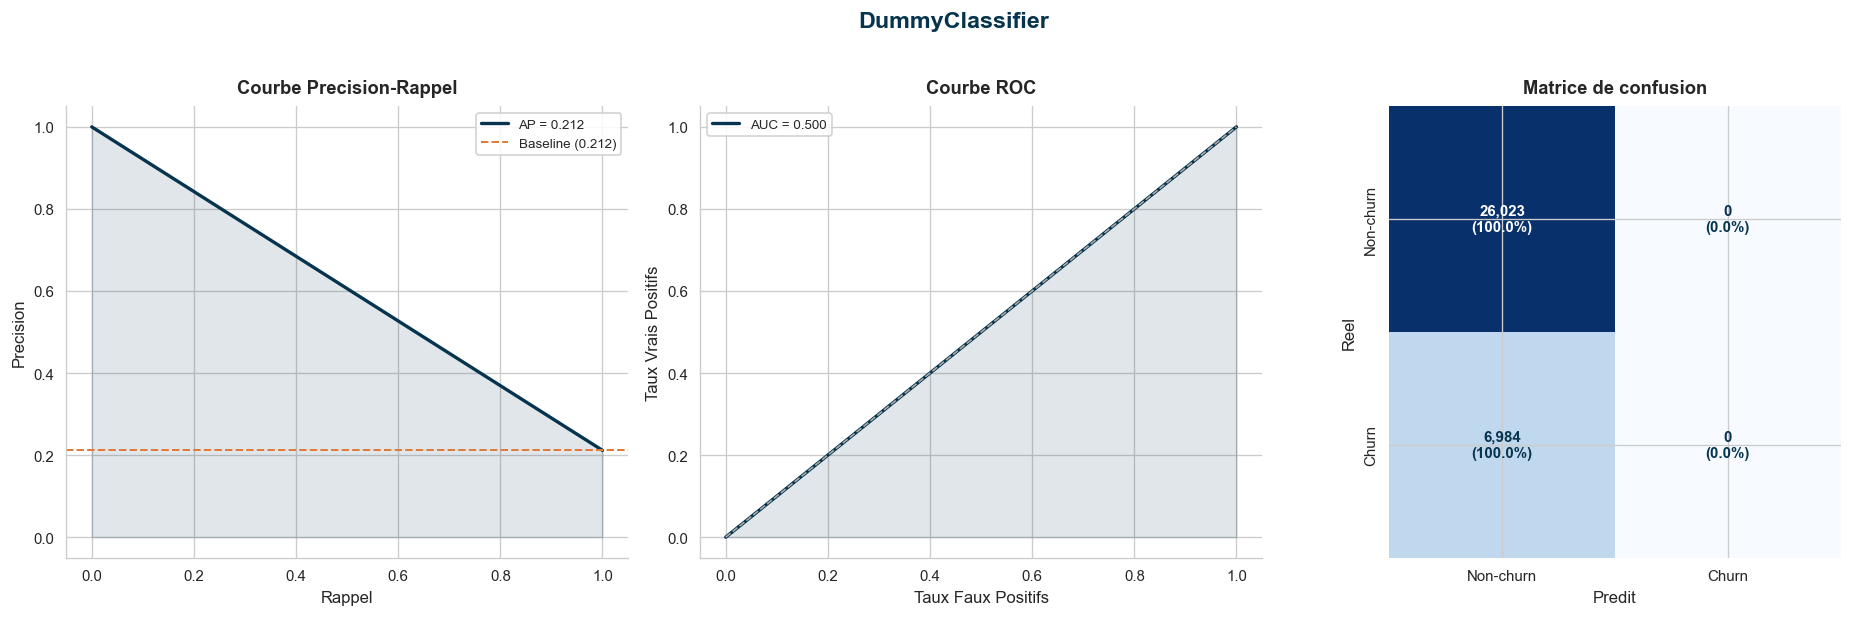

{'roc_auc': 0.5,
 'accuracy': 0.7884,
 'recall': 0.0,
 'precision': 0.0,
 'f2_weighted': 0.7482,
 'lift_10pct': np.float64(0.9968),
 'train_time_s': 0.5}

In [6]:
pipeline_dummy = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DummyClassifier(strategy='prior', random_state=RANDOM_STATE)),
])
evaluate_model(pipeline_dummy, 'DummyClassifier')

<a id="section-6"></a>
# Section 6 : Gaussian Naive Bayes

Classifieur probabiliste basé sur le théorème de Bayes avec hypothèse d'**indépendance conditionnelle** et distribution gaussienne. Très rapide et interprétable.

Les probabilités a priori sont calculées sur les données et reflètent naturellement le déséquilibre (~21 % de churners).

── GaussianNB  |  CV bench (132,027 obs.)  |  cv_time = 5.1 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
GaussianNB,0.7985,0.7889,0.505,0.5013,0.789,5.1


── GaussianNB  |  Jeu de test  |  train_time = 0.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
GaussianNB,0.7954,0.788,0.5087,0.4989,0.7883,3.0276,0.6


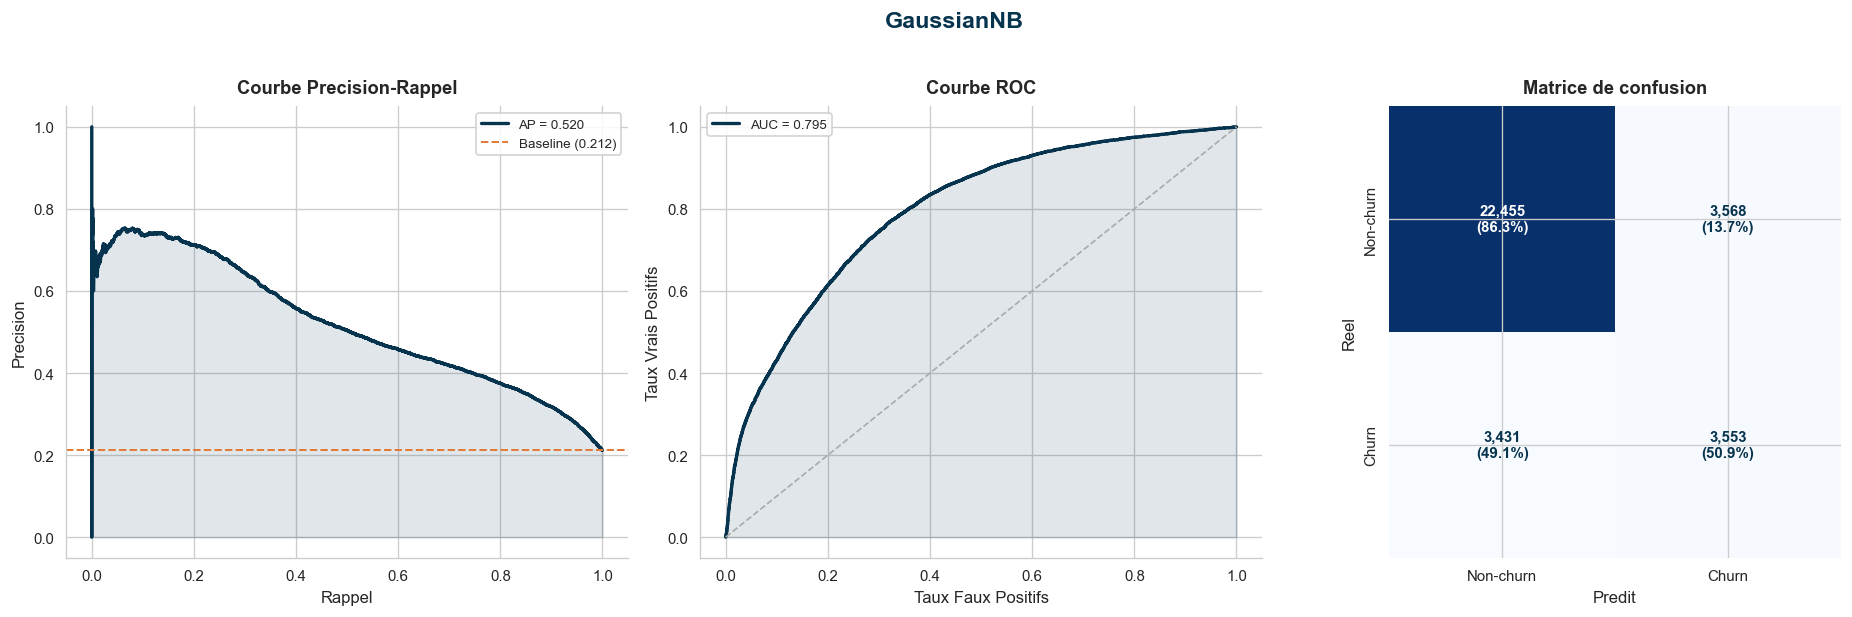

{'roc_auc': 0.7954,
 'accuracy': 0.788,
 'recall': 0.5087,
 'precision': 0.4989,
 'f2_weighted': 0.7883,
 'lift_10pct': np.float64(3.0276),
 'train_time_s': 0.6}

In [7]:
pipeline_gnb = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', GaussianNB()),
])
evaluate_model(pipeline_gnb, 'GaussianNB')

<a id="section-7"></a>
# Section 7 : Decision Tree

Arbre de décision unique entraîné par **partitionnement récursif** (critère Gini), limité à `max_depth=8`. Très interprétable mais sensible au surapprentissage.

Entraîné sans `class_weight` : minimise l'impureté selon la fréquence naturelle des classes.

── DecisionTree  |  CV bench (132,027 obs.)  |  cv_time = 7.9 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
DecisionTree,0.8796,0.8608,0.5391,0.7327,0.8567,7.9


── DecisionTree  |  Jeu de test  |  train_time = 3.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
DecisionTree,0.8829,0.8619,0.5455,0.7337,0.858,3.9169,3.2


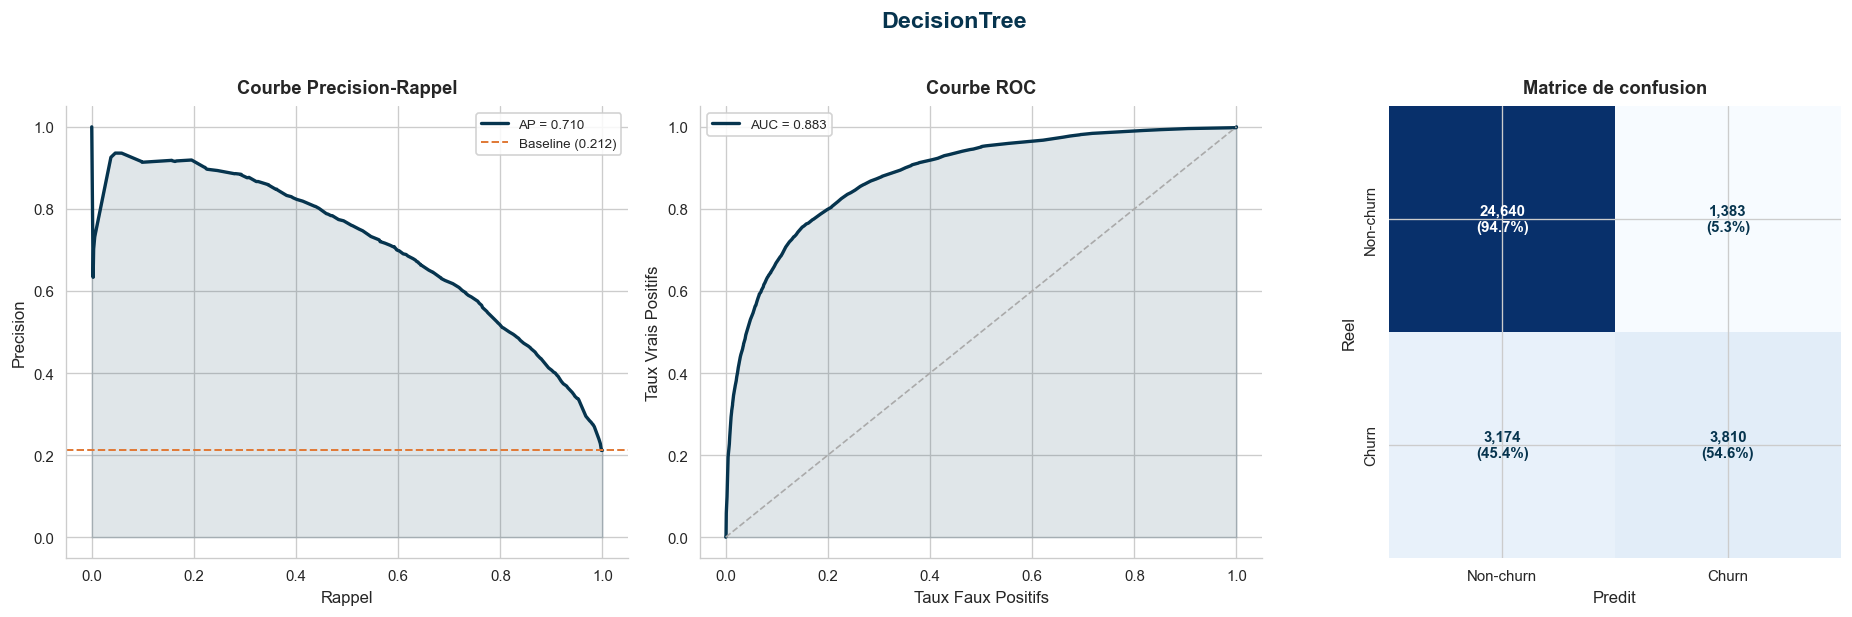

{'roc_auc': 0.8829,
 'accuracy': 0.8619,
 'recall': 0.5455,
 'precision': 0.7337,
 'f2_weighted': 0.858,
 'lift_10pct': np.float64(3.9169),
 'train_time_s': 3.2}

In [8]:
pipeline_dt = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_dt, 'DecisionTree')

<a id="section-8"></a>
# Section 8 : K-Nearest Neighbors

Prédiction par **vote majoritaire** parmi les k=15 plus proches voisins. Méthode non paramétrique, sensible à l'échelle (d'où la standardisation).

`weights='uniform'` : chaque voisin a le même poids — pas de correction du déséquilibre.

── KNN  |  CV bench (132,027 obs.)  |  cv_time = 271.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
KNN,0.8599,0.8537,0.5063,0.7192,0.8487,271.8


── KNN  |  Jeu de test  |  train_time = 1.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
KNN,0.8604,0.8549,0.5092,0.7234,0.85,3.7393,1.2


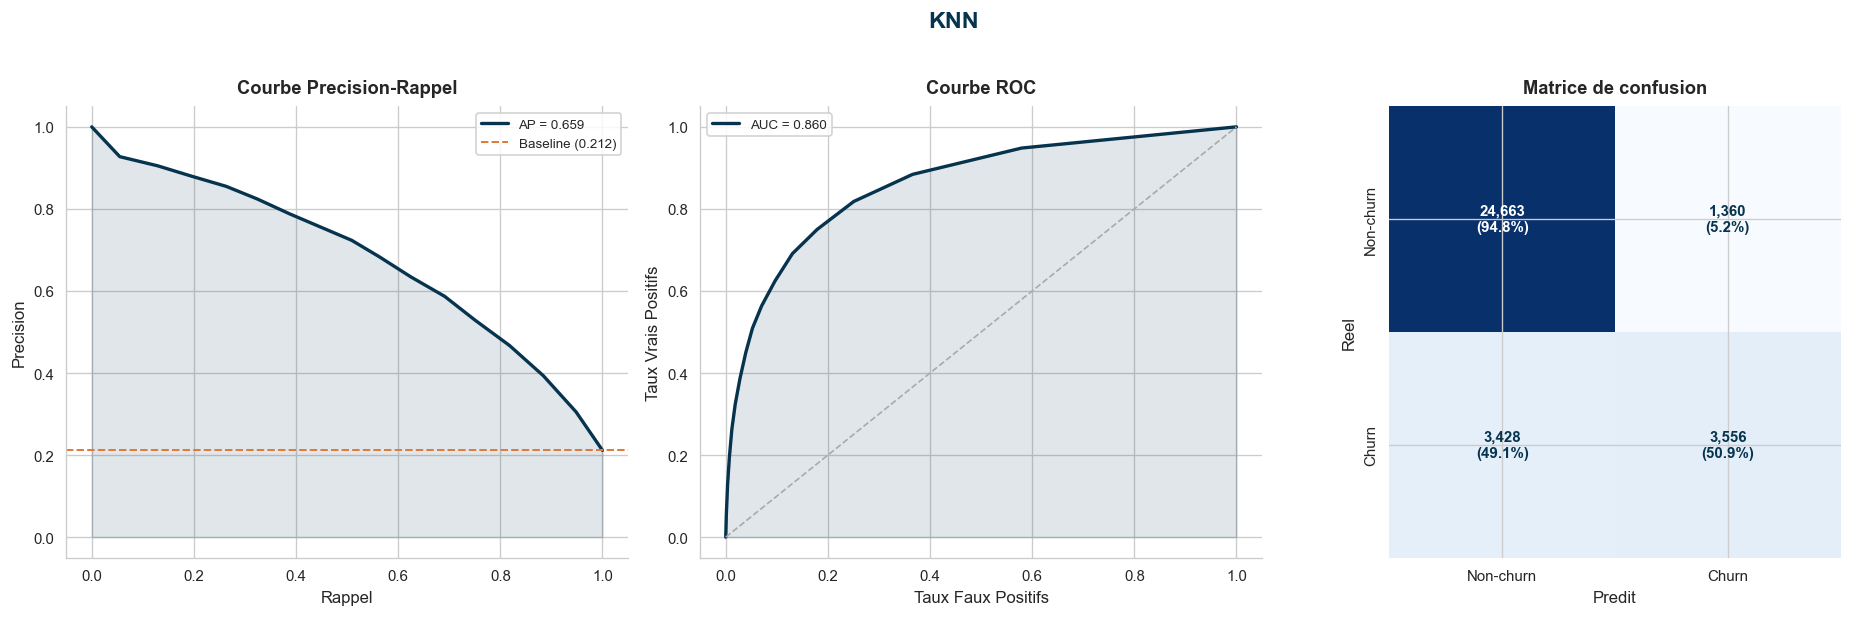

{'roc_auc': 0.8604,
 'accuracy': 0.8549,
 'recall': 0.5092,
 'precision': 0.7234,
 'f2_weighted': 0.85,
 'lift_10pct': np.float64(3.7393),
 'train_time_s': 1.2}

In [9]:
pipeline_knn = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', KNeighborsClassifier(n_neighbors=15, weights='uniform')),
])
evaluate_model(pipeline_knn, 'KNN')

<a id="section-9"></a>
# Section 9 : AdaBoost

**Boosting adaptatif** : chaque itération augmente le poids des observations mal classées. Utilise des stumps (arbres à 1 nœud). Sensible au bruit.

Entraîné sans correction : le stump de base n'a pas de `class_weight`.

── AdaBoost  |  CV bench (132,027 obs.)  |  cv_time = 13.0 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
AdaBoost,0.8763,0.8562,0.4749,0.7549,0.8495,13.0


── AdaBoost  |  Jeu de test  |  train_time = 22.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
AdaBoost,0.876,0.8565,0.4702,0.7598,0.8495,3.8725,22.8


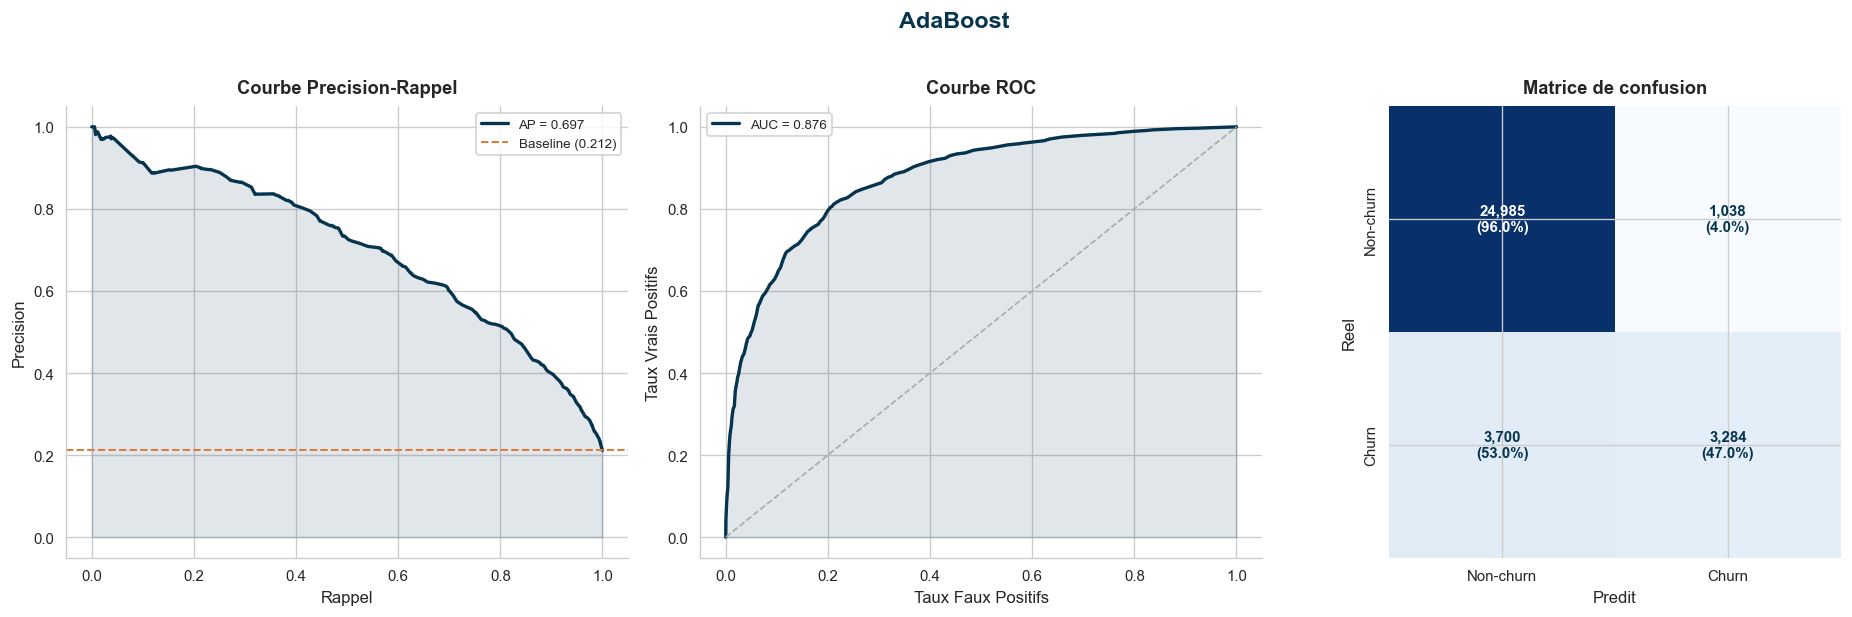

{'roc_auc': 0.876,
 'accuracy': 0.8565,
 'recall': 0.4702,
 'precision': 0.7598,
 'f2_weighted': 0.8495,
 'lift_10pct': np.float64(3.8725),
 'train_time_s': 22.8}

In [10]:
base_dt = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
pipeline_ada = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', AdaBoostClassifier(
        estimator=base_dt,
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_ada, 'AdaBoost')

<a id="section-10"></a>
# Section 10 : Random Forest

Ensemble d'arbres entraînés sur des **sous-échantillons bootstrap** avec sélection aléatoire de variables. Réduit la variance par agrégation (bagging). Robuste aux outliers.

Entraîné sans `class_weight` : les arbres pondèrent les classes selon leur fréquence naturelle.

── RandomForest  |  CV bench (132,027 obs.)  |  cv_time = 26.7 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
RandomForest,0.8741,0.8588,0.5346,0.7258,0.8547,26.7


── RandomForest  |  Jeu de test  |  train_time = 16.3 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
RandomForest,0.8742,0.8585,0.5308,0.7266,0.8542,3.8725,16.3


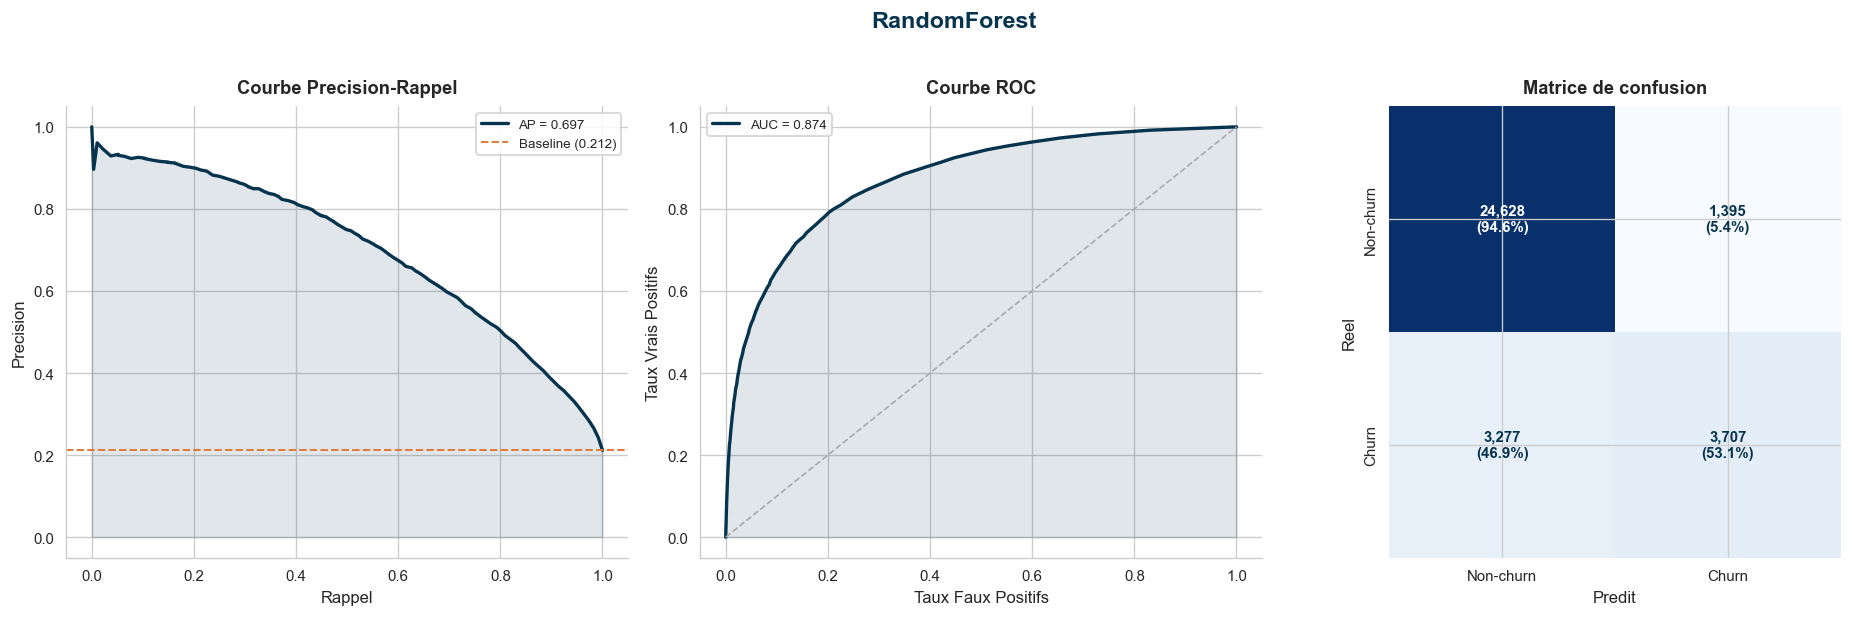

{'roc_auc': 0.8742,
 'accuracy': 0.8585,
 'recall': 0.5308,
 'precision': 0.7266,
 'f2_weighted': 0.8542,
 'lift_10pct': np.float64(3.8725),
 'train_time_s': 16.3}

In [11]:
pipeline_rf = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
evaluate_model(pipeline_rf, 'RandomForest')

<a id="section-11"></a>
# Section 11 : Extra Trees

Variante du Random Forest où les **seuils de coupure sont tirés aléatoirement**. Entraînement plus rapide, variance encore plus réduite.

Entraîné sans `class_weight`.

── ExtraTrees  |  CV bench (132,027 obs.)  |  cv_time = 35.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
ExtraTrees,0.8663,0.8542,0.5305,0.7075,0.8503,35.6


── ExtraTrees  |  Jeu de test  |  train_time = 9.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
ExtraTrees,0.8656,0.854,0.5292,0.7072,0.8501,3.8124,9.6


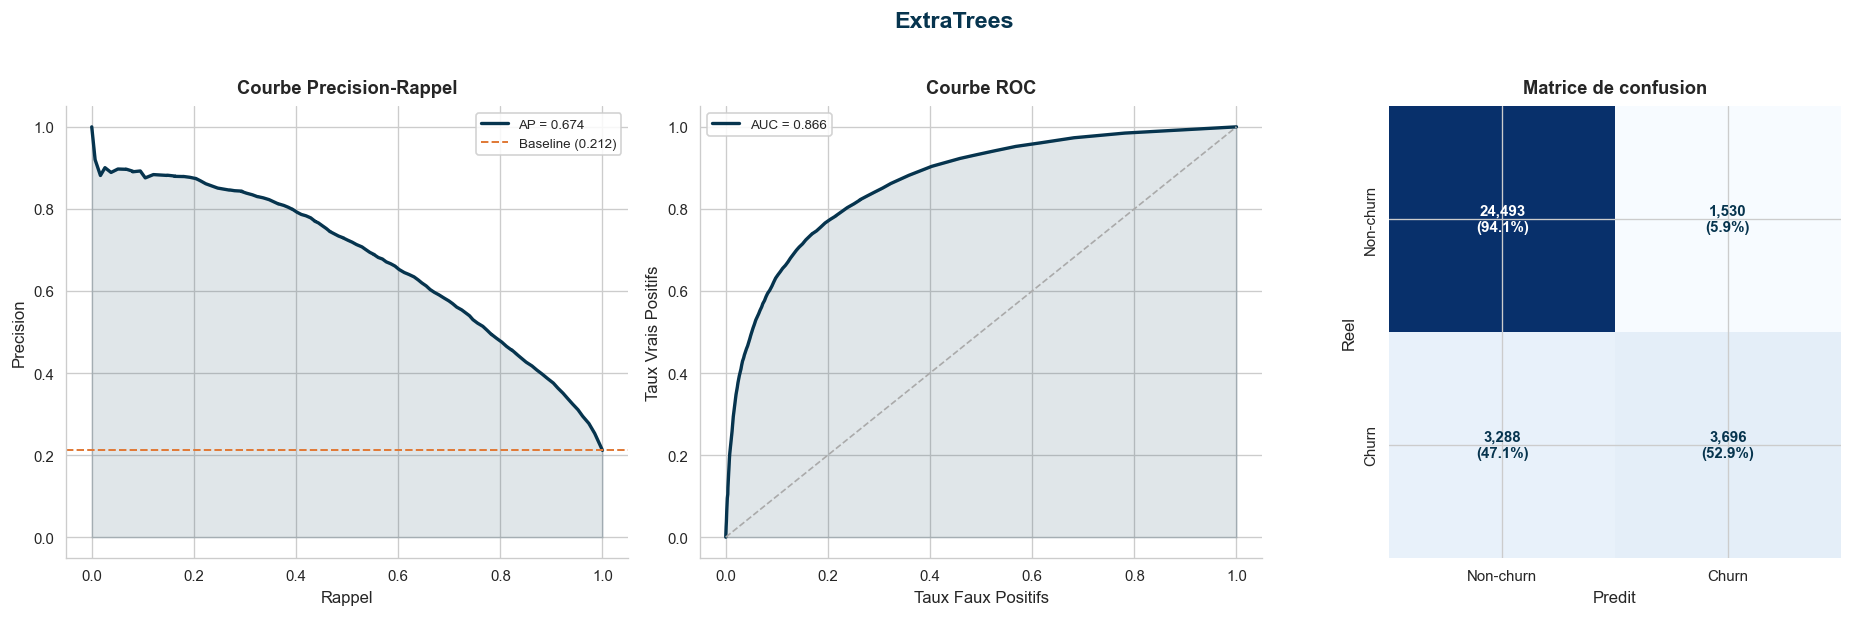

{'roc_auc': 0.8656,
 'accuracy': 0.854,
 'recall': 0.5292,
 'precision': 0.7072,
 'f2_weighted': 0.8501,
 'lift_10pct': np.float64(3.8124),
 'train_time_s': 9.6}

In [12]:
pipeline_et = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', ExtraTreesClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
evaluate_model(pipeline_et, 'ExtraTrees')

<a id="section-12"></a>
# Section 12 : Gradient Boosting

**Construction séquentielle** d'arbres : chaque arbre corrige les erreurs résiduelles du précédent par descente de gradient sur la log-loss. Généralement très précis mais lent.

Paramètres par défaut — pas de mécanisme de rééquilibrage (`class_weight` non supporté nativement dans sklearn).

> ⚠️ GradientBoosting est séquentiel — la CV est lancée avec `cv_njobs=1` pour éviter la surcharge mémoire.

── GradientBoosting  |  CV bench (132,027 obs.)  |  cv_time = 219.3 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
GradientBoosting,0.8888,0.8652,0.5511,0.7455,0.8613,219.3


── GradientBoosting  |  Jeu de test  |  train_time = 69.1 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
GradientBoosting,0.8894,0.8652,0.5471,0.7482,0.8611,3.9713,69.1


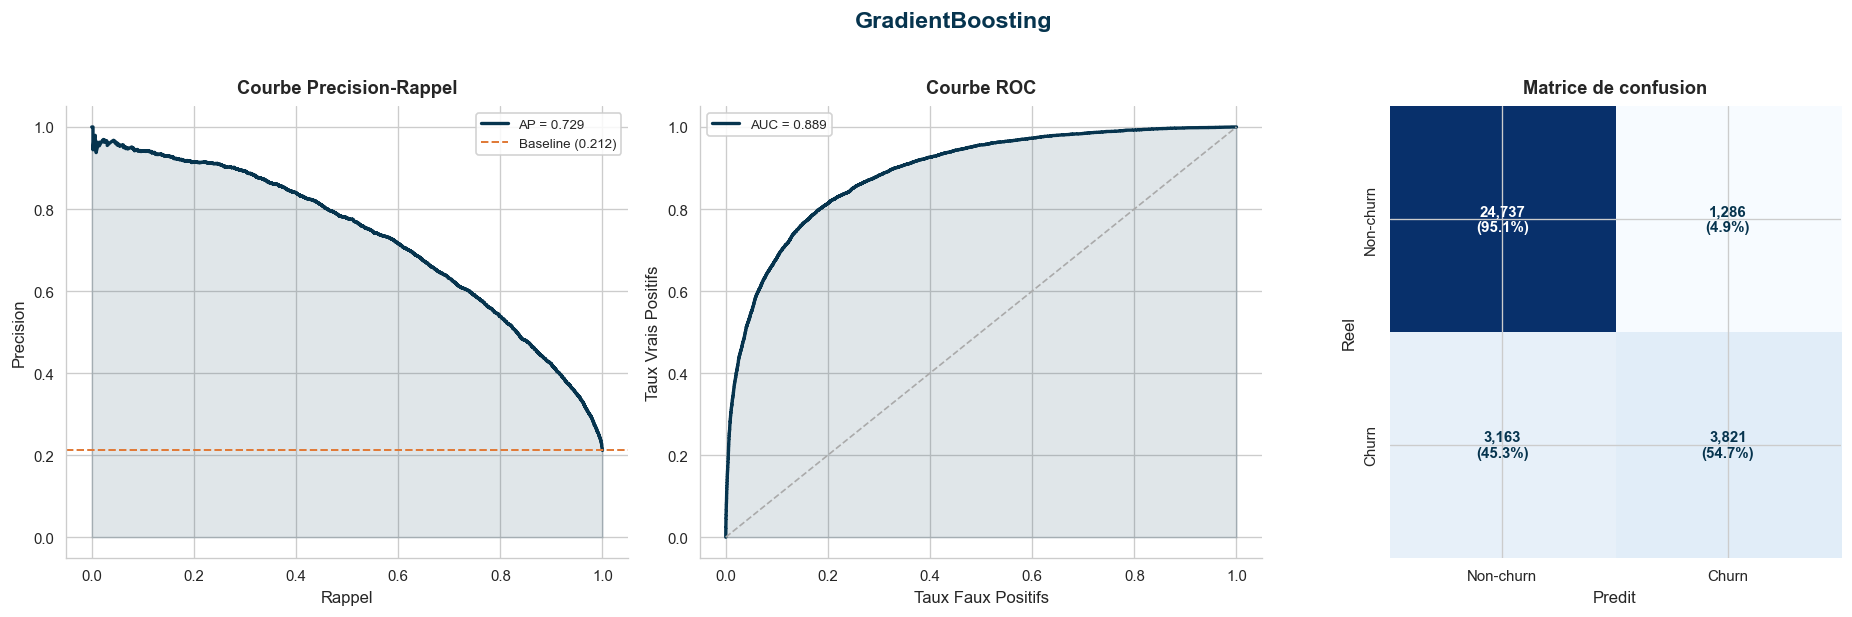

{'roc_auc': 0.8894,
 'accuracy': 0.8652,
 'recall': 0.5471,
 'precision': 0.7482,
 'f2_weighted': 0.8611,
 'lift_10pct': np.float64(3.9713),
 'train_time_s': 69.1}

In [13]:
pipeline_gb = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_gb, 'GradientBoosting', cv_njobs=1)

<a id="section-13"></a>
# Section 13 : XGBoost

Gradient boosting optimisé avec **régularisation L1/L2**, élagage des arbres et parallélisation. Généralement l'un des meilleurs algorithmes sur données tabulaires.

`scale_pos_weight=1` : aucun rééquilibrage, toutes les observations ont le même poids.

── XGBoost  |  CV bench (132,027 obs.)  |  cv_time = 3.9 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
XGBoost,0.8812,0.8621,0.5578,0.7268,0.8586,3.9


── XGBoost  |  Jeu de test  |  train_time = 1.3 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
XGBoost,0.8842,0.8642,0.5596,0.7354,0.8607,3.9327,1.3


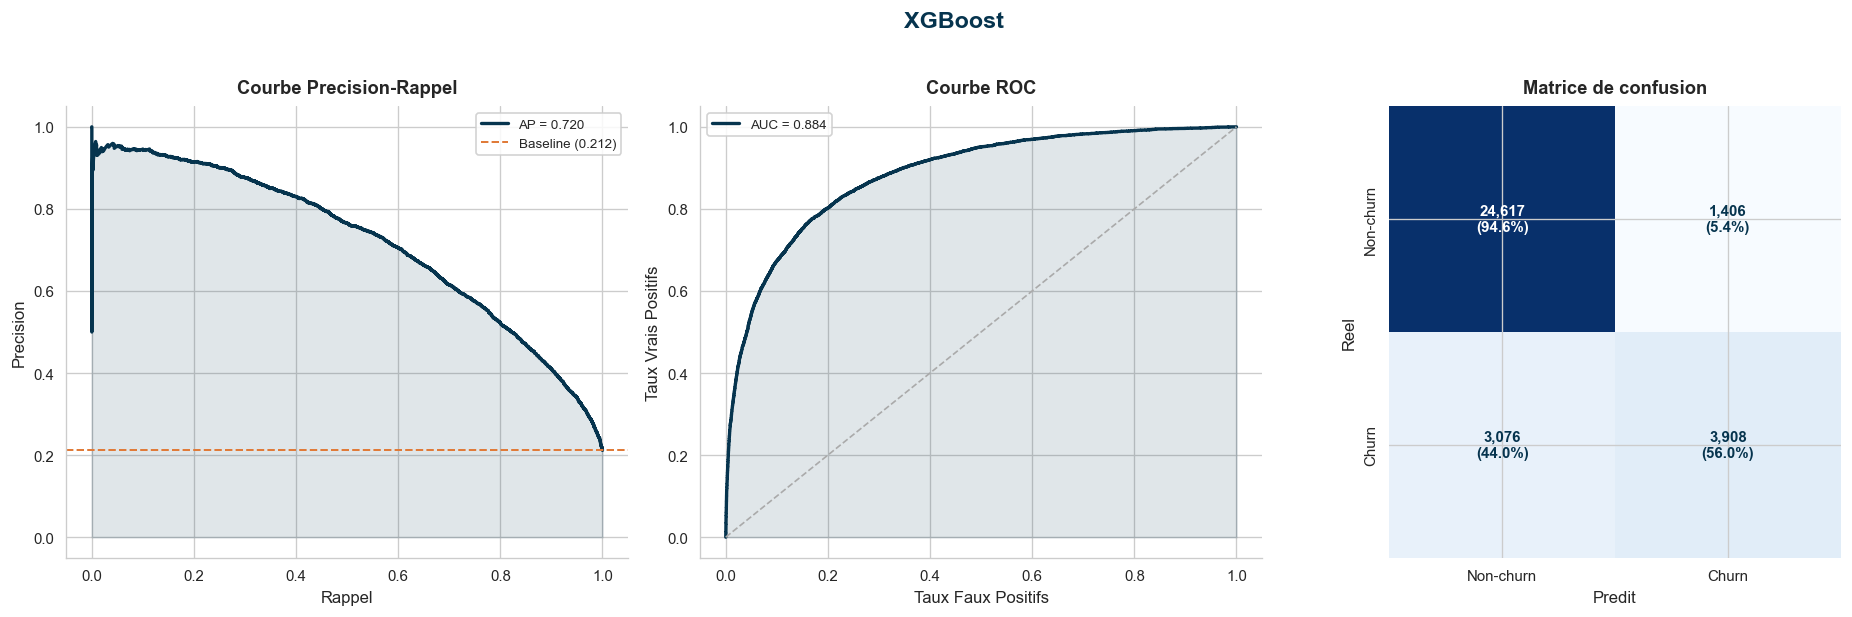

In [14]:
if HAS_XGB:
    pipeline_xgb = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', XGBClassifier(
            n_estimators=150,
            scale_pos_weight=1,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
            n_jobs=-1,
        )),
    ])
    evaluate_model(pipeline_xgb, 'XGBoost', cv_njobs=1)
else:
    print('XGBoost non disponible — pip install xgboost')

<a id="section-14"></a>
# Section 14 : LightGBM

Gradient boosting basé sur des **histogrammes de features**. Très rapide sur les grands datasets grâce à la croissance feuille par feuille.

Entraîné sans `is_unbalance` : classes pondérées selon leur fréquence naturelle.

── LightGBM  |  CV bench (132,027 obs.)  |  cv_time = 3.9 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
LightGBM,0.8879,0.8654,0.559,0.7414,0.8618,3.9


── LightGBM  |  Jeu de test  |  train_time = 1.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
LightGBM,0.8891,0.8654,0.5566,0.7426,0.8617,3.9599,1.2


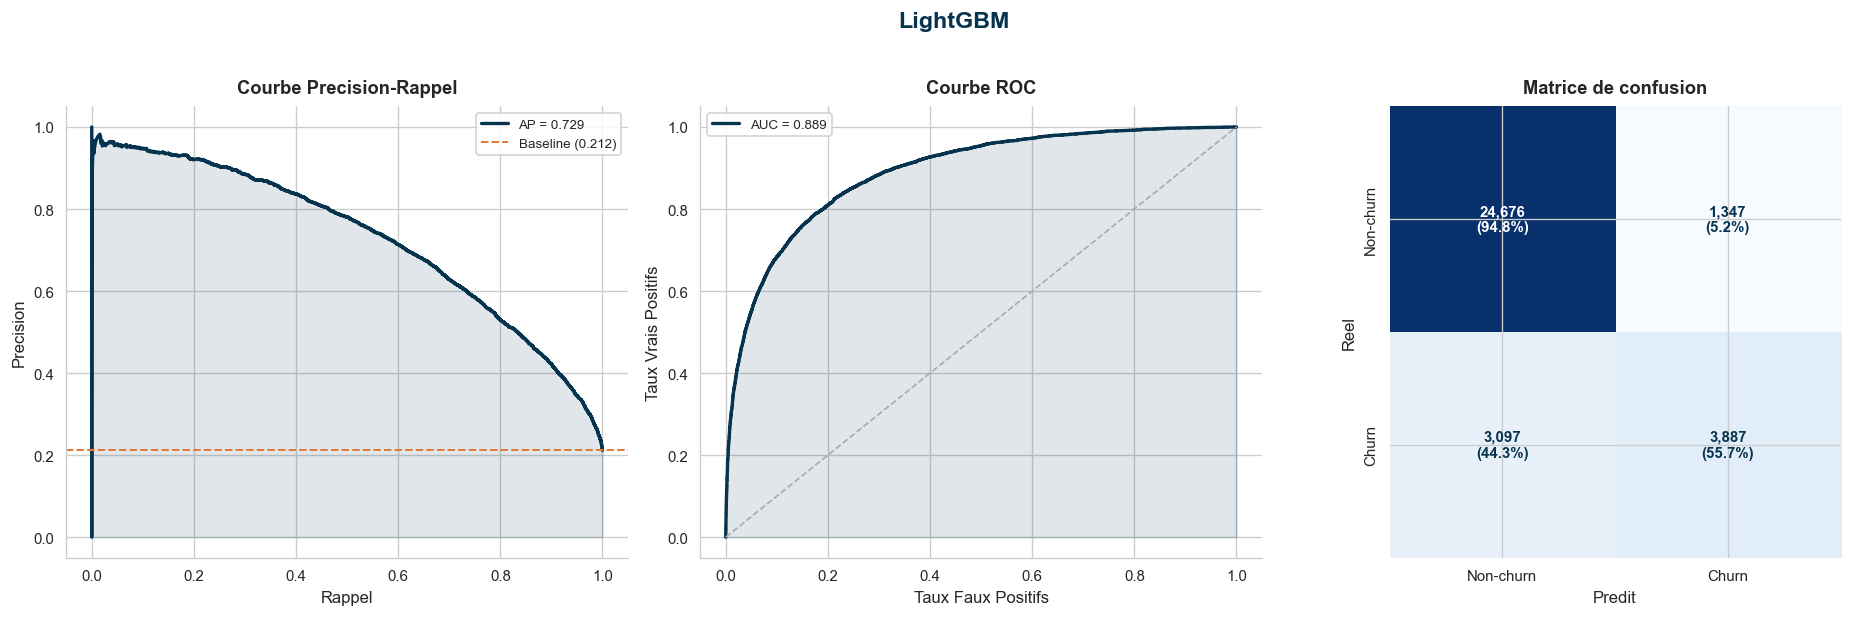

In [15]:
if HAS_LGBM:
    pipeline_lgbm = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LGBMClassifier(
            n_estimators=150,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        )),
    ])
    evaluate_model(pipeline_lgbm, 'LightGBM', cv_njobs=1)
else:
    print('LightGBM non disponible — pip install lightgbm')

<a id="section-15"></a>
# Section 15 : Comparaison des modèles

Critère de sélection : Le **F2-weighted** représente notre metrique prioritaire de choix (favorise le rappel des churners). Nous utilisons aussi le **Lift@10 %** pour l'utilité opérationnelle.

In [16]:
df_cv = (
    pd.DataFrame(cv_results)
    .T
    .rename_axis('modele')
    .sort_values('f2_weighted', ascending=False)
)
print('Résultats — Validation croisée (benchmark, 30 000 obs.) :')
display(df_cv)

Résultats — Validation croisée (benchmark, 30 000 obs.) :


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
modele,,,,,,
LightGBM,0.8879,0.8654,0.5590,0.7414,0.8618,3.9
GradientBoosting,0.8888,0.8652,0.5511,0.7455,0.8613,219.3
XGBoost,0.8812,0.8621,0.5578,0.7268,0.8586,3.9
DecisionTree,0.8796,0.8608,0.5391,0.7327,0.8567,7.9
RandomForest,0.8741,0.8588,0.5346,0.7258,0.8547,26.7
ExtraTrees,0.8663,0.8542,0.5305,0.7075,0.8503,35.6
AdaBoost,0.8763,0.8562,0.4749,0.7549,0.8495,13.0
KNN,0.8599,0.8537,0.5063,0.7192,0.8487,271.8
GaussianNB,0.7985,0.7889,0.5050,0.5013,0.7890,5.1


In [17]:
df_test = (
    pd.DataFrame(test_results)
    .T
    .rename_axis('modele')
    .sort_values('f2_weighted', ascending=False)
)
print('Résultats — Jeu de test :')
display(df_test)

Résultats — Jeu de test :


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,train_time_s
modele,,,,,,,
LightGBM,0.8891,0.8654,0.5566,0.7426,0.8617,3.9599,1.2
GradientBoosting,0.8894,0.8652,0.5471,0.7482,0.8611,3.9713,69.1
XGBoost,0.8842,0.8642,0.5596,0.7354,0.8607,3.9327,1.3
DecisionTree,0.8829,0.8619,0.5455,0.7337,0.8580,3.9169,3.2
RandomForest,0.8742,0.8585,0.5308,0.7266,0.8542,3.8725,16.3
ExtraTrees,0.8656,0.8540,0.5292,0.7072,0.8501,3.8124,9.6
KNN,0.8604,0.8549,0.5092,0.7234,0.8500,3.7393,1.2
AdaBoost,0.8760,0.8565,0.4702,0.7598,0.8495,3.8725,22.8
GaussianNB,0.7954,0.7880,0.5087,0.4989,0.7883,3.0276,0.6


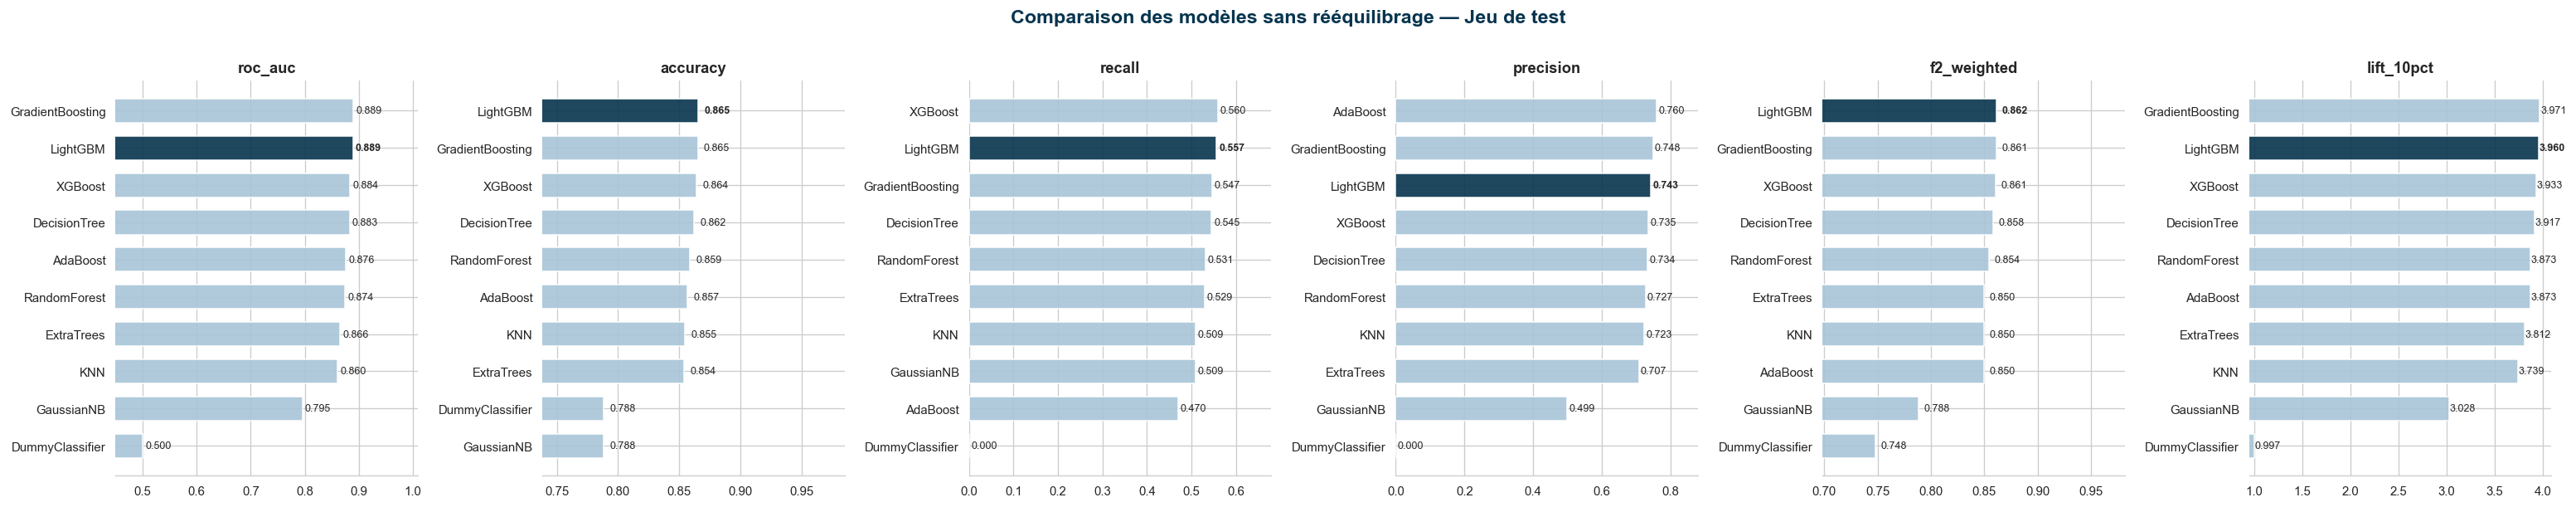

Meilleur modèle (F2-weighted) : LightGBM


In [18]:
metrics_to_plot = ['roc_auc', 'accuracy', 'recall', 'precision', 'f2_weighted', 'lift_10pct']
best_model_name = df_test['f2_weighted'].idxmax()

fig, axes = plt.subplots(1, 6, figsize=(26, 5))
fig.patch.set_facecolor('white')

for ax, metric in zip(axes, metrics_to_plot):
    col_data = df_test[metric].dropna().sort_values()
    colors = ['#06344e' if m == best_model_name else '#a8c5d8' for m in col_data.index]
    ax.barh(col_data.index, col_data.values, color=colors, alpha=0.9,
            edgecolor='white', height=0.65)
    ax.set_title(metric, fontweight='bold', fontsize=11, pad=6)
    xlim_lo = max(0, col_data.min() - 0.05)
    xlim_hi = col_data.max() + 0.12
    ax.set_xlim(xlim_lo, xlim_hi)
    for i, (m, v) in enumerate(zip(col_data.index, col_data.values)):
        fw = 'bold' if m == best_model_name else 'normal'
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=7.5, fontweight=fw)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', left=False)

fig.suptitle('Comparaison des modèles sans rééquilibrage — Jeu de test',
             fontsize=14, fontweight='bold', color='#06344e', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'benchmark_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Meilleur modèle (F2-weighted) : {best_model_name}')

<a id="section-16"></a>
# Section 16 : Tuning du meilleur modele

Optimisation des hyperparametres par **Optuna** (*Tree-structured Parzen Estimator* - TPE) sur X_train complet :

| Parametre | Valeur | Justification |
|---|---|---|
| **Algorithme** | TPE | Modelise la distribution des bons parametres, plus efficace que la recherche aleatoire a budget egal. |
| **Essais** | 50 | Chaque essai evalue le pipeline sur 3 folds -> 150 fits au total. |
| **Scorer** | F2-weighted | Coherent avec le critere de selection du benchmark. |
| **Reentrainement** | X_train complet | Optimisation et reentrainement sur le meme ensemble -> pas de decalage de distribution. |

In [19]:
N_TRIALS = 50
N_FOLDS  = 3

_NO_TUNE = {'DummyClassifier'}


def _suggest_params(trial, model_name):
    if model_name == 'LightGBM':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.35, log=True),
            'model__num_leaves'       : trial.suggest_int('num_leaves', 15, 150),
            'model__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'model__subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'model__reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 2.0),
            'model__reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 2.0),
        }
    if model_name == 'XGBoost':
        return {
            'model__n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'model__learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.35, log=True),
            'model__max_depth'       : trial.suggest_int('max_depth', 2, 10),
            'model__subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'model__reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 3.0),
            'model__reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 3.0),
            'model__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
    if model_name == 'GradientBoosting':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
            'model__learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'model__max_depth'        : trial.suggest_int('max_depth', 2, 8),
            'model__subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'RandomForest':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__max_depth'        : trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20, 25]),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 15),
            'model__max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        }
    if model_name == 'ExtraTrees':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__max_depth'        : trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 15),
        }
    if model_name == 'DecisionTree':
        return {
            'model__max_depth'        : trial.suggest_int('max_depth', 2, 20),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 20),
            'model__max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
    if model_name == 'KNN':
        return {
            'model__n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
            'model__weights'    : trial.suggest_categorical('weights', ['uniform', 'distance']),
            'model__metric'     : trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
        }
    if model_name == 'AdaBoost':
        return {
            'model__n_estimators' : trial.suggest_int('n_estimators', 50, 300),
            'model__learning_rate': trial.suggest_float('learning_rate', 0.005, 1.5),
        }
    if model_name == 'GaussianNB':
        return {
            'model__var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-5, log=True),
        }
    return {}


def objective(trial):
    params = _suggest_params(trial, best_model_name)
    p = clone(trained_models[best_model_name])
    p.set_params(**params)
    cv_optuna = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        p, X_bench, y_bench,
        cv=cv_optuna, scoring=f2_weighted_scorer, n_jobs=-1,
    )
    return float(np.mean(scores['test_score']))


if not HAS_OPTUNA or best_model_name in _NO_TUNE:
    reason = 'Optuna non disponible' if not HAS_OPTUNA else f'pas de paramètres à optimiser pour {best_model_name}'
    print(f'Tuning ignoré : {reason}.')
    tuned_pipeline = trained_models[best_model_name]
    tuning_results = None
    best_cv_score  = None
else:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    tuning_results = pd.DataFrame([
        {'trial': t.number, 'mean_test_score': t.value, **t.params}
        for t in study.trials if t.value is not None
    ])
    best_cv_score = study.best_value

    best_params_optuna = {f'model__{k}': v for k, v in study.best_params.items()}
    tuned_pipeline = clone(trained_models[best_model_name])
    tuned_pipeline.set_params(**best_params_optuna)
    tuned_pipeline.fit(X_train, y_train)

    print(f'\nMeilleur F2-weighted CV (bench) : {best_cv_score:.4f}')
    print('Meilleurs paramètres :')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')

Best trial: 30. Best value: 0.862449: 100%|██████████| 50/50 [11:30<00:00, 13.80s/it]



Meilleur F2-weighted CV (bench) : 0.8624
Meilleurs paramètres :
  n_estimators: 268
  learning_rate: 0.0666108862017018
  num_leaves: 16
  min_child_samples: 84
  subsample: 0.5995313472634043
  colsample_bytree: 0.7995197872145816
  reg_alpha: 0.4583094267549169
  reg_lambda: 0.41460000640330424


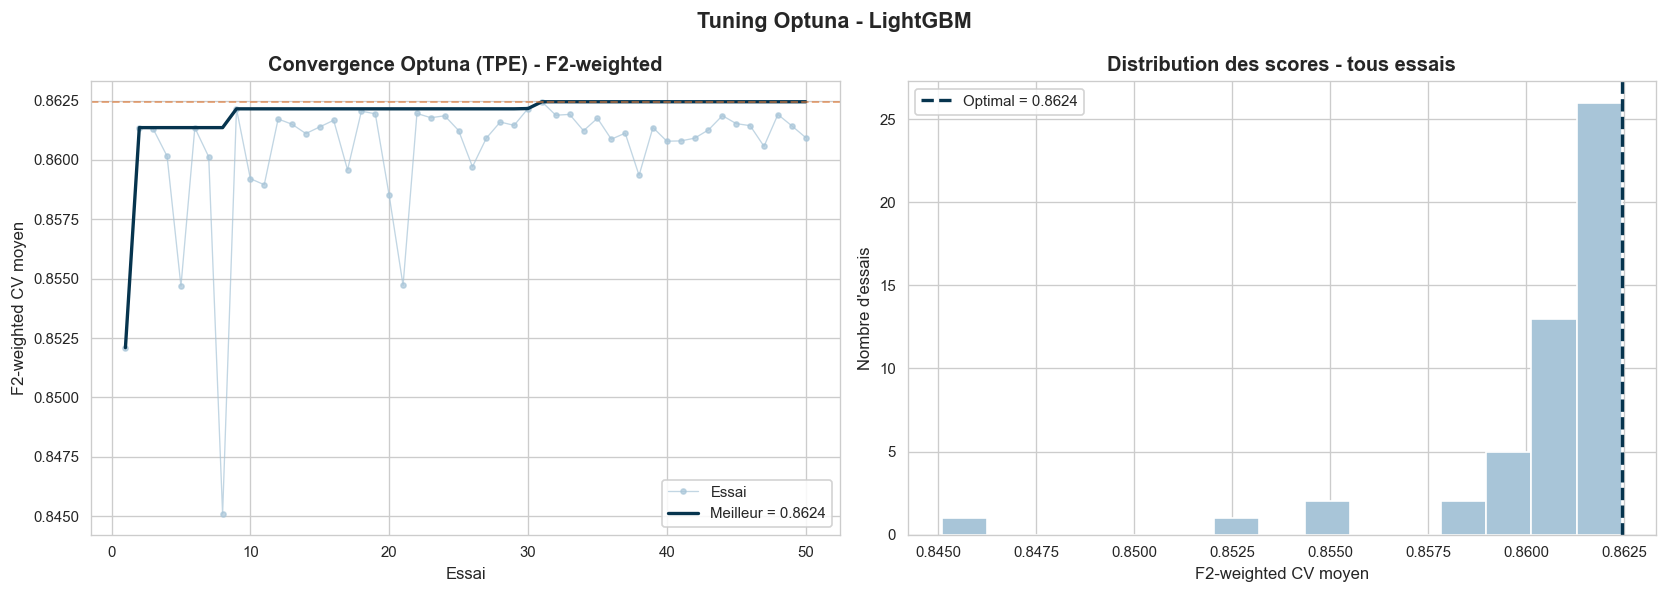

In [20]:
if tuning_results is not None:
    cummax = np.maximum.accumulate(tuning_results['mean_test_score'].fillna(-np.inf))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        tuning_results['trial'] + 1,
        tuning_results['mean_test_score'],
        marker='o', ms=3, linewidth=0.8, color='#a8c5d8', alpha=0.7, label='Essai',
    )
    axes[0].plot(
        tuning_results['trial'] + 1,
        cummax,
        color='#06344e', linewidth=2, label=f'Meilleur = {best_cv_score:.4f}',
    )
    axes[0].axhline(best_cv_score, color='#e07b39', linestyle='--', linewidth=1.2, alpha=0.6)
    axes[0].set_title('Convergence Optuna (TPE) - F2-weighted', fontweight='bold')
    axes[0].set_xlabel('Essai')
    axes[0].set_ylabel('F2-weighted CV moyen')
    axes[0].legend()

    axes[1].hist(tuning_results['mean_test_score'].dropna(), bins=15,
                 color='#a8c5d8', edgecolor='white')
    axes[1].axvline(best_cv_score, color='#06344e', linestyle='--', linewidth=2,
                    label=f'Optimal = {best_cv_score:.4f}')
    axes[1].set_title('Distribution des scores - tous essais', fontweight='bold')
    axes[1].set_xlabel('F2-weighted CV moyen')
    axes[1].set_ylabel("Nombre d'essais")
    axes[1].legend()

    plt.suptitle(f'Tuning Optuna - {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'tuning_history.png', dpi=300, bbox_inches='tight')
    plt.show()

<a id="section-17"></a>
# Section 17 : Évaluation finale

Comparaison avant / après tuning sur le jeu de test, puis analyse détaillée du modèle retenu.

In [21]:
rows = [
    {'modele': 'Avant tuning', **compute_test_metrics(trained_models[best_model_name], X_test, y_test)},
]
if tuning_results is not None:
    rows.append({'modele': 'Après tuning', **compute_test_metrics(tuned_pipeline, X_test, y_test)})

final_metrics_df = pd.DataFrame(rows).set_index('modele')
display(final_metrics_df)

eval_pipeline = tuned_pipeline if tuning_results is not None else trained_models[best_model_name]
y_pred  = eval_pipeline.predict(X_test)
y_score = eval_pipeline.predict_proba(X_test)[:, 1]

print(f'\nRapport de classification — {best_model_name} :')
print(classification_report(y_test, y_pred, target_names=['Non-churn', 'Churn'], digits=4))

,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct
modele,,,,,,
Avant tuning,0.8891,0.8654,0.5566,0.7426,0.8617,3.9599
Après tuning,0.8901,0.8659,0.5610,0.7425,0.8624,3.9900



Rapport de classification — LightGBM :
              precision    recall  f1-score   support

   Non-churn     0.8894    0.9478    0.9177     26023
       Churn     0.7425    0.5610    0.6391      6984

    accuracy                         0.8659     33007
   macro avg     0.8160    0.7544    0.7784     33007
weighted avg     0.8583    0.8659    0.8587     33007



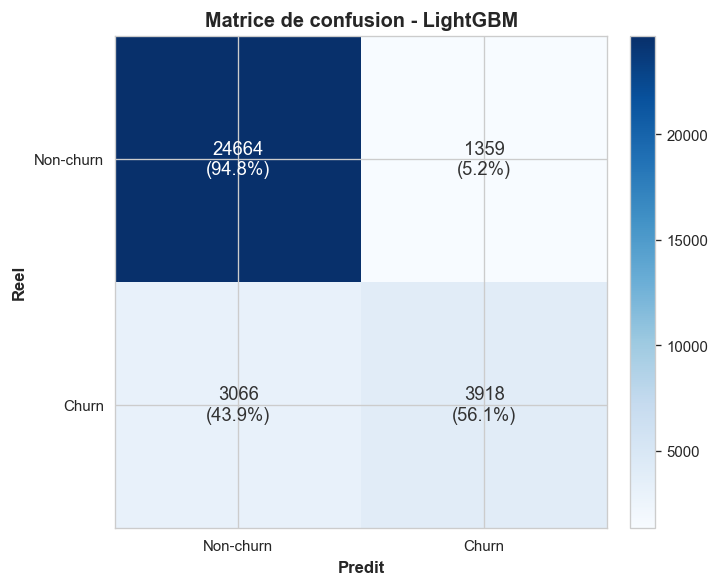

In [22]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
labels = ['Non-churn', 'Churn']
for r in range(2):
    for c in range(2):
        pct = cm[r, c] / cm[r].sum() * 100
        ax.text(c, r, f'{cm[r, c]}\n({pct:.1f}%)',
                ha='center', va='center', fontsize=11,
                color='white' if cm[r, c] > cm.max() / 2 else '#333333')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predit', fontweight='bold')
ax.set_ylabel('Reel', fontweight='bold')
ax.set_title(f'Matrice de confusion - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

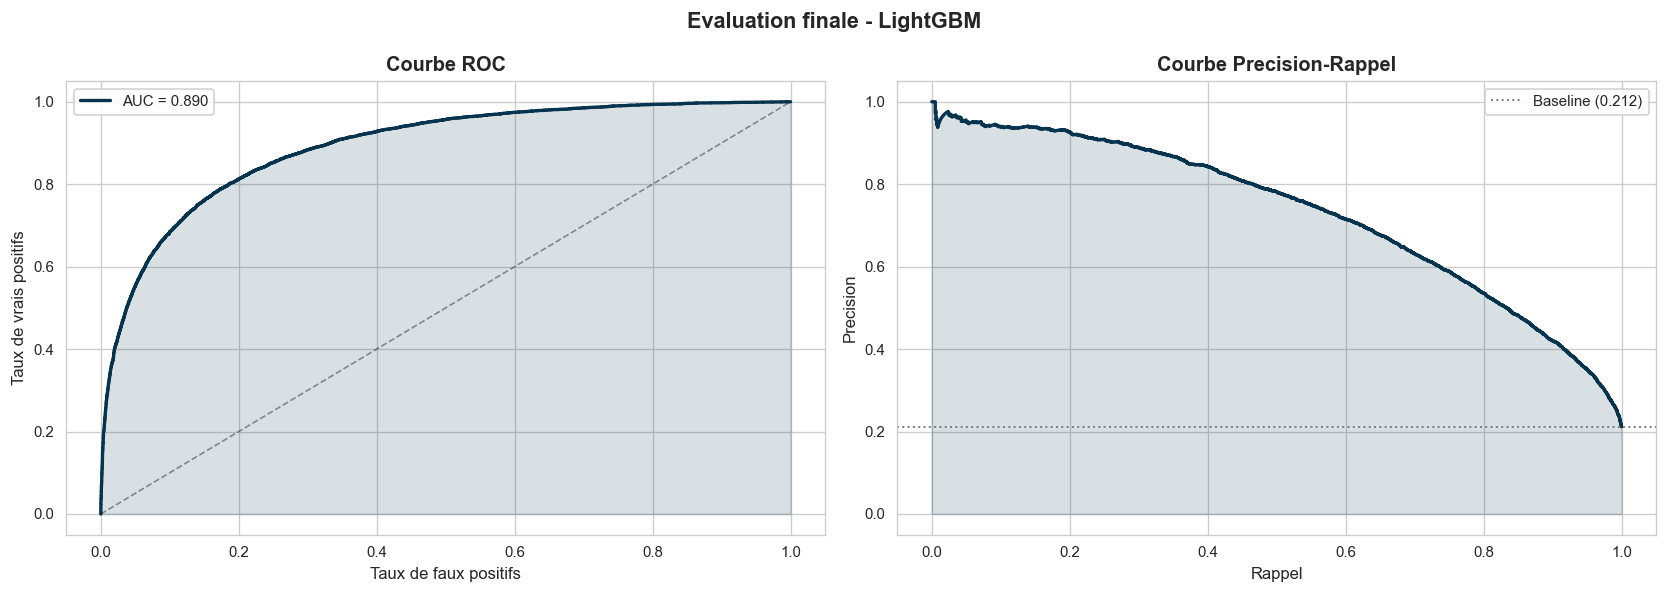

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_score)
auc_val = roc_auc_score(y_test, y_score)
axes[0].plot(fpr, tpr, color='#06344e', linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#06344e')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
axes[0].set_title('Courbe ROC', fontweight='bold')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_score)
axes[1].plot(rec, prec, color='#06344e', linewidth=2)
axes[1].fill_between(rec, prec, alpha=0.15, color='#06344e')
axes[1].axhline(y_test.mean(), color='grey', linestyle=':', linewidth=1.2,
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_title('Courbe Precision-Rappel', fontweight='bold')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle(f'Evaluation finale - {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

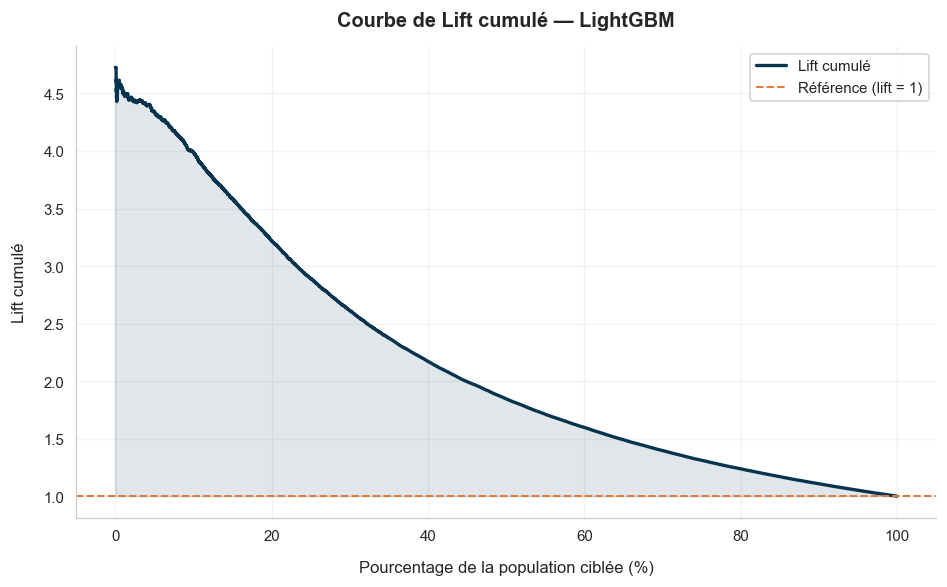

Lift@10% : 3.99x
Lift@20% : 3.22x
Lift@30% : 2.61x


In [27]:
# Courbe de lift cumulé
y_true_lift = y_test.reset_index(drop=True)

df_lift = pd.DataFrame({"y_true": y_true_lift, "y_proba": y_score})
df_lift = df_lift.sort_values("y_proba", ascending=False).reset_index(drop=True)

rate_pos           = df_lift["y_true"].mean()
df_lift["cum_pos"] = df_lift["y_true"].cumsum()
df_lift["n"]       = np.arange(1, len(df_lift) + 1)
df_lift["lift"]    = (df_lift["cum_pos"] / df_lift["n"]) / rate_pos
df_lift["pct_pop"] = df_lift["n"] / len(df_lift) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_lift["pct_pop"], df_lift["lift"],
        color="#06344e", lw=2, label="Lift cumulé")
ax.fill_between(df_lift["pct_pop"], df_lift["lift"], 1,
                where=(df_lift["lift"] >= 1),
                alpha=0.12, color="#06344e")
ax.axhline(y=1, color="#e07b39", linestyle="--", lw=1.2, label="Référence (lift = 1)")
ax.set_xlabel("Pourcentage de la population ciblée (%)", labelpad=10)
ax.set_ylabel("Lift cumulé", labelpad=10)
ax.set_title("Courbe de Lift cumulé — " + best_model_name, fontweight="bold", pad=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "lift_curve.png", dpi=300, bbox_inches="tight")
plt.show()

for pct in [10, 20, 30]:
    n        = max(1, int(len(df_lift) * pct / 100))
    lift_val = df_lift.loc[n - 1, "lift"]
    print("Lift@" + str(pct) + "% : " + str(round(lift_val, 2)) + "x")

,feature,importance
1,Age,565
0,CreditScore,543
7,EstimatedSalary,448
3,Balance,343
14,Salary_Age,333
4,NumOfProducts,317
12,Tenure_Age_Ratio,317
11,Balance_per_Product,266
13,Balance_Age_Ratio,243
6,IsActiveMember,159


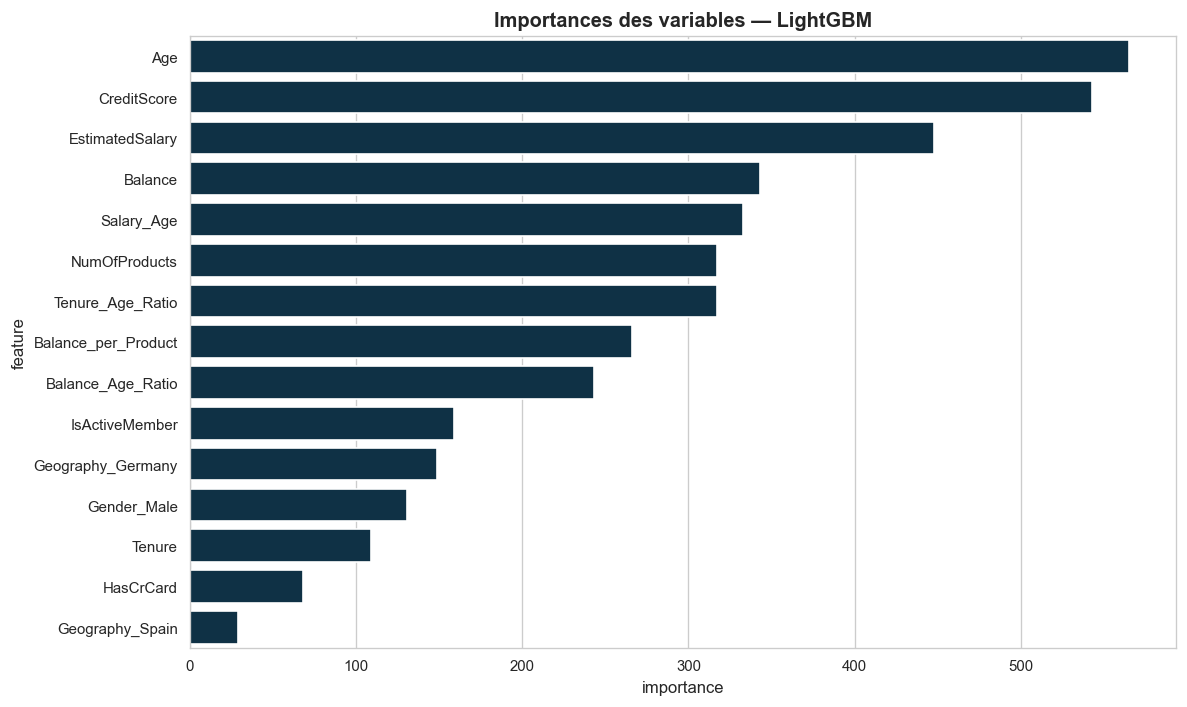

In [24]:
model_step = eval_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature'   : X.columns,
        'importance': model_step.feature_importances_,
    }).sort_values('importance', ascending=False)
    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#06344e')
    plt.title(f'Importances des variables — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Le modèle retenu ne fournit pas d\'importance de variables directement.')

<a id="section-18"></a>
# Section 18 : Synthèse

## Récapitulatif des choix

**Métriques** : F2-weighted retenu comme critère principal car il combine rappel (× 2). Le Lift@10 % valide l'utilité opérationnelle pour les campagnes de rétention ciblées.

**Référence** : ce notebook entraîne tous les modèles **sans traitement du déséquilibre** (paramètres par défaut). Comparer avec le notebook 03b pour mesurer l'apport du rééquilibrage.

## Résultats finaux

In [25]:
print(f'Meilleur modèle : {best_model_name}')
print()
display(final_metrics_df)

Meilleur modèle : LightGBM



,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct
modele,,,,,,
Avant tuning,0.8891,0.8654,0.5566,0.7426,0.8617,3.9599
Après tuning,0.8901,0.8659,0.5610,0.7425,0.8624,3.9900


<a id="section-19"></a>
# Section 19 : Sauvegarde du meilleur modèle

Le pipeline final (`tuned_pipeline` ou `trained_models[best_model_name]`) est sérialisé en **trois formats** complémentaires :

| Format | Outil | Cas d'usage |
|---|---|---|
| **joblib** | `joblib.dump` | Recommandé pour les objets NumPy/sklearn : stockage efficace des grands tableaux via `mmap`. |
| **pickle** | `pickle.dump` | Sérialisation Python standard, compatible avec tous les environnements sans dépendance supplémentaire. |
| **dill** | `dill.dump` | Extension de pickle : supporte les lambdas, closures et fonctions locales (utile si le pipeline contient des scorers personnalisés). |

Les fichiers sont enregistrés dans `best_model/` à la racine du projet.

In [26]:
import pickle
import joblib
import dill

BEST_MODEL_DIR = PROJECT_ROOT / 'best_model'
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_name_clean = best_model_name.lower().replace(' ', '_')

joblib_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.joblib'
joblib.dump(eval_pipeline, joblib_path)
print(f'joblib  -> {joblib_path}')

pkl_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(eval_pipeline, f)
print(f'pickle  -> {pkl_path}')

dill_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.dill'
with open(dill_path, 'wb') as f:
    dill.dump(eval_pipeline, f)
print(f'dill    -> {dill_path}')

print(f"\nModele '{best_model_name}' sauvegarde en 3 formats dans : {BEST_MODEL_DIR}")

joblib  -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\lightgbm_pipeline.joblib
pickle  -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\lightgbm_pipeline.pkl
dill    -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\lightgbm_pipeline.dill

Modele 'LightGBM' sauvegarde en 3 formats dans : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model
